## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

## 2. Load Data

In [2]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')
print('Shape:', df.shape)
df.head()

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 3. Feature Engineering

In [3]:
data = df.copy()

data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y', errors='coerce')
latest_date = data['Dt_Customer'].max()
data['Customer_Days'] = (latest_date - data['Dt_Customer']).dt.days

data['Age'] = 2026 - data['Year_Birth']
data['Total_Children'] = data['Kidhome'] + data['Teenhome']

spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
data['Total_Spending'] = data[spend_cols].sum(axis=1)

campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
data['Total_Accepted'] = data[campaign_cols].sum(axis=1)

data['Income_Per_Child'] = data['Income'] / (data['Total_Children'] + 1)
data['Web_Purchase_Rate'] = data['NumWebPurchases'] / (data['NumWebVisitsMonth'] + 1)

data = data.drop(columns=['ID', 'Dt_Customer', 'Year_Birth'])
data.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Z_CostContact,Z_Revenue,Response,Customer_Days,Age,Total_Children,Total_Spending,Total_Accepted,Income_Per_Child,Web_Purchase_Rate
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,3,11,1,663,69,0,1617,0,58138.0,1.000000
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,3,11,0,113,72,2,27,0,15448.0,0.166667
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,3,11,0,312,61,0,776,0,71613.0,1.600000
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,3,11,0,139,42,1,53,0,13323.0,0.285714
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,3,11,0,161,45,1,422,0,29146.5,0.833333


## 4. Prepare Features and Target

In [4]:
X = data.drop(columns=['Response'])
y = data['Response']

categorical_features = ['Education', 'Marital_Status']
numeric_features = [col for col in X.columns if col not in categorical_features]

print('Target distribution:')
print(y.value_counts(normalize=True))

Target distribution:
Response
0    0.850893
1    0.149107
Name: proportion, dtype: float64


## 5. Build and Train the Model

In [5]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=400,
        class_weight='balanced',
        random_state=42
    ))
])

rf_pipeline.fit(X, y)
print('Random Forest model trained.')

Random Forest model trained.


## 6. Random Forest Feature Importance

In [6]:
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['model'].feature_importances_

rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

rf_importance_df.head(15)

,Feature,Importance
3,num__Recency,0.091614
23,num__Customer_Days,0.083271
27,num__Total_Accepted,0.072099
26,num__Total_Spending,0.061227
28,num__Income_Per_Child,0.056153
6,num__MntMeatProducts,0.055693
9,num__MntGoldProds,0.048704
4,num__MntWines,0.047567
0,num__Income,0.046492
14,num__NumWebVisitsMonth,0.036213


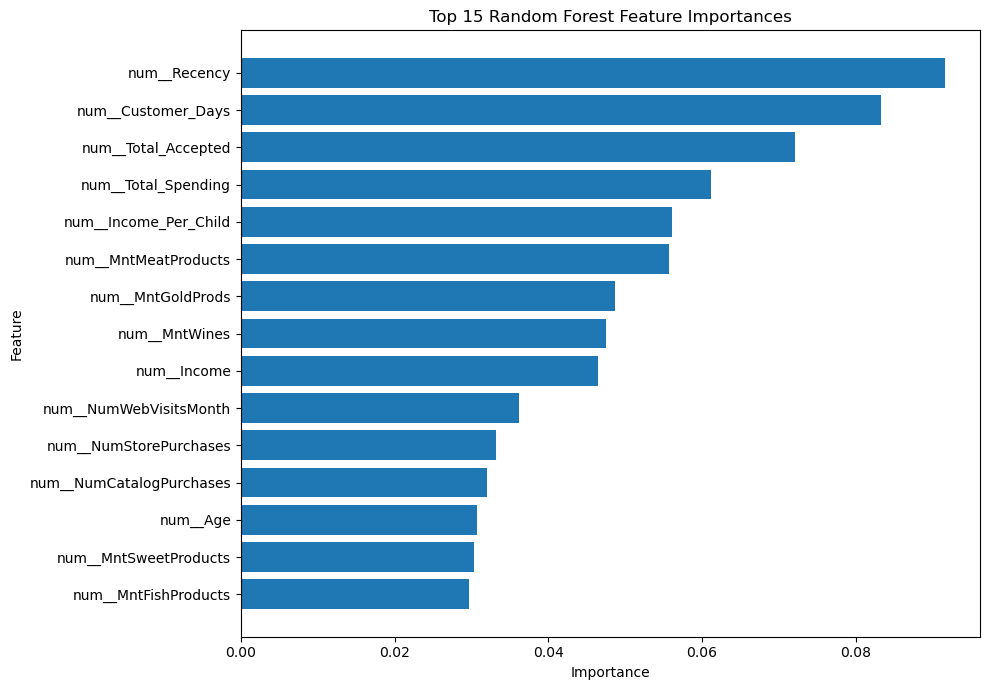

In [7]:
top_rf = rf_importance_df.head(15).iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(top_rf['Feature'], top_rf['Importance'])
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. Permutation Importance

In [8]:
perm = permutation_importance(
    rf_pipeline,
    X,
    y,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance Mean': perm.importances_mean,
    'Importance Std': perm.importances_std
}).sort_values(by='Importance Mean', ascending=False)

perm_importance_df.head(15)

,Feature,Importance Mean,Importance Std
5,Recency,0.005636,0.000484
25,Customer_Days,0.002983,0.000279
29,Total_Accepted,0.002758,0.000267
30,Income_Per_Child,0.001539,0.000193
1,Marital_Status,0.001320,0.000257
8,MntMeatProducts,0.001218,0.000283
28,Total_Spending,0.001161,0.000142
16,NumWebVisitsMonth,0.001096,0.000123
11,MntGoldProds,0.001036,0.000227
15,NumStorePurchases,0.000732,0.000090


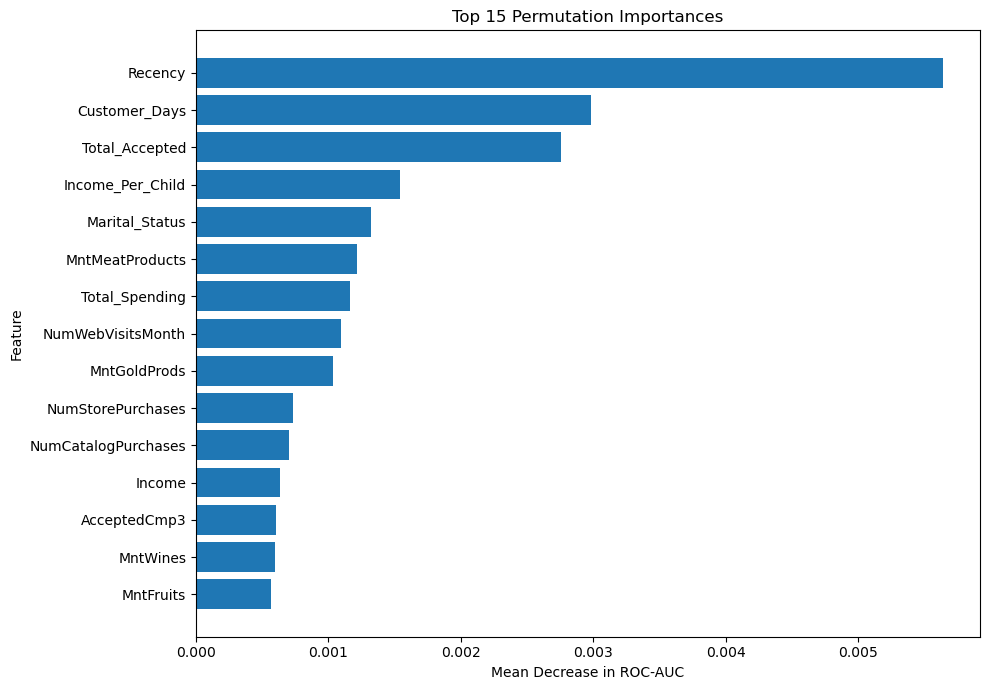

In [9]:
top_perm = perm_importance_df.head(15).iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(top_perm['Feature'], top_perm['Importance Mean'])
plt.title('Top 15 Permutation Importances')
plt.xlabel('Mean Decrease in ROC-AUC')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Key Findings

In [10]:
print('Top 10 Random Forest features:')
print(rf_importance_df.head(10).to_string(index=False))

print('\nTop 10 permutation importance features:')
print(perm_importance_df.head(10).to_string(index=False))

Top 10 Random Forest features:
               Feature  Importance
          num__Recency    0.091614
    num__Customer_Days    0.083271
   num__Total_Accepted    0.072099
   num__Total_Spending    0.061227
 num__Income_Per_Child    0.056153
  num__MntMeatProducts    0.055693
     num__MntGoldProds    0.048704
         num__MntWines    0.047567
           num__Income    0.046492
num__NumWebVisitsMonth    0.036213

Top 10 permutation importance features:
          Feature  Importance Mean  Importance Std
          Recency         0.005636        0.000484
    Customer_Days         0.002983        0.000279
   Total_Accepted         0.002758        0.000267
 Income_Per_Child         0.001539        0.000193
   Marital_Status         0.001320        0.000257
  MntMeatProducts         0.001218        0.000283
   Total_Spending         0.001161        0.000142
NumWebVisitsMonth         0.001096        0.000123
     MntGoldProds         0.001036        0.000227
NumStorePurchases         0.00073